# Total Time Spent on Test
Checks the time the candidate spend on the whole test. The test will be marked as "too slow" if the time it took was more than the mean plus the standard deviation and marked as "too fast" if the time it took was more than the mean minus the standard deviation. 

In [1]:
import pandas as pd
import pyodbc  
import matplotlib.pyplot as plt

## Import Data from csv

In [2]:
sjt_question = pd.read_csv("../../../decoded_data/SJT/FactQuestionSJT.csv")

## Data Inspection

In [3]:
sjt_question.head()

,QuestionKey,InstanceID,ItemID,AnswerSequence1,AnswerSequence2,AnswerSequence3,TimeSpent,Test,TestKey
0,1,1,1,5,4,2,181,SJT,160065
1,2,1,2,4,3,2,172,SJT,160065
2,3,1,3,4,2,3,136,SJT,160065
3,4,1,4,3,2,4,266,SJT,160065
4,5,1,5,2,5,1,198,SJT,160065


In [4]:
sjt_question.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89622 entries, 0 to 89621
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   QuestionKey      89622 non-null  int64 
 1   InstanceID       89622 non-null  int64 
 2   ItemID           89622 non-null  int64 
 3   AnswerSequence1  89622 non-null  int64 
 4   AnswerSequence2  89622 non-null  int64 
 5   AnswerSequence3  89622 non-null  int64 
 6   TimeSpent        89622 non-null  int64 
 7   Test             89622 non-null  object
 8   TestKey          89622 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 6.2+ MB


## Data Preparation

In [5]:
df = sjt_question[["TestKey", "TimeSpent"]]

df_timespent = df.groupby('TestKey')['TimeSpent'].sum().reset_index()
df_timespent.head()

,TestKey,TimeSpent
0,160065,2915
1,160066,2048
2,160067,0
3,160068,0
4,160069,3962


## Statistics
LET OP: hier gedaan op hele kleine steekproef, dit moet berekend worden op de populatie! 

In [6]:
mu = df_timespent.TimeSpent.mean()
sigma = df_timespent.TimeSpent.std()

print("Mean:", mu)
print("Standard deviation:", sigma)

Mean: 902.0881926312736
Standard deviation: 1681.2806354476131


## Data Labelling

### Too slow
We will now figure out on which tests the candidate spent "too much time". 

In [7]:
too_slow = (df_timespent.TimeSpent > (mu + sigma) )

df_timespent['TooSlow'] = False
df_timespent.loc[too_slow, 'TooSlow'] = True

### Too fast
We will now figure out on which tests the candidate spent "too little time". 

In [8]:
too_fast = (df_timespent.TimeSpent < (mu - sigma) )

df_timespent['TooFast'] = False
df_timespent.loc[too_fast, 'TooFast'] = True

## Exporting Data with Anomaly Check

In [9]:
df_timespent

,TestKey,TimeSpent,TooSlow,TooFast
0,160065,2915,True,False
1,160066,2048,False,False
2,160067,0,False,False
3,160068,0,False,False
4,160069,3962,True,False
...,...,...,...,...
6889,166954,0,False,False
6890,166955,0,False,False
6891,166956,0,False,False
6892,166957,0,False,False


In [10]:
df_timespent['is_anomaly'] = df_timespent.TooFast | df_timespent.TooSlow
df_timespent.is_anomaly = df_timespent.is_anomaly.astype(int)
df_timespent.head()

,TestKey,TimeSpent,TooSlow,TooFast,is_anomaly
0,160065,2915,True,False,1
1,160066,2048,False,False,0
2,160067,0,False,False,0
3,160068,0,False,False,0
4,160069,3962,True,False,1


In [11]:
df_timespent.to_csv("../csv/time_spent_test_checked.csv", index=False)

## Visualisation

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

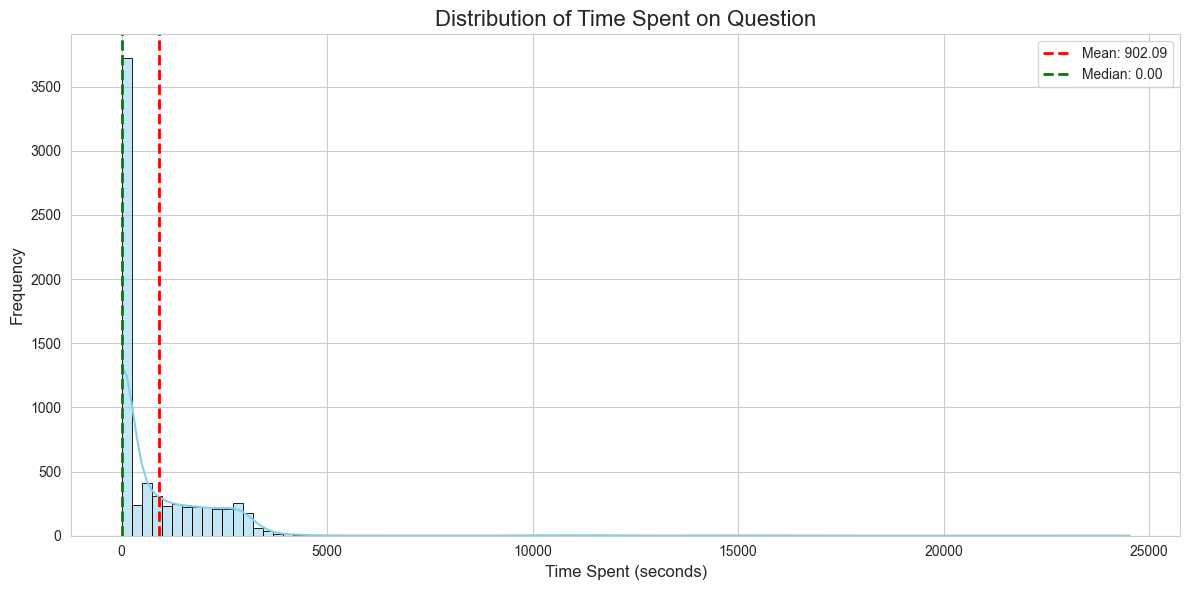

In [13]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# kernel density estimation
sns.histplot(data=df_timespent, x='TimeSpent', kde=True, color='skyblue', edgecolor='black', bins=100)

# name 
plt.title('Distribution of Time Spent on Question', fontsize=16)
plt.xlabel('Time Spent (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add summary statistics
mean_time = df_timespent['TimeSpent'].mean()
median_time = df_timespent['TimeSpent'].median()

plt.axvline(mean_time, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_time:.2f}')
plt.axvline(median_time, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_time:.2f}')

plt.legend()

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

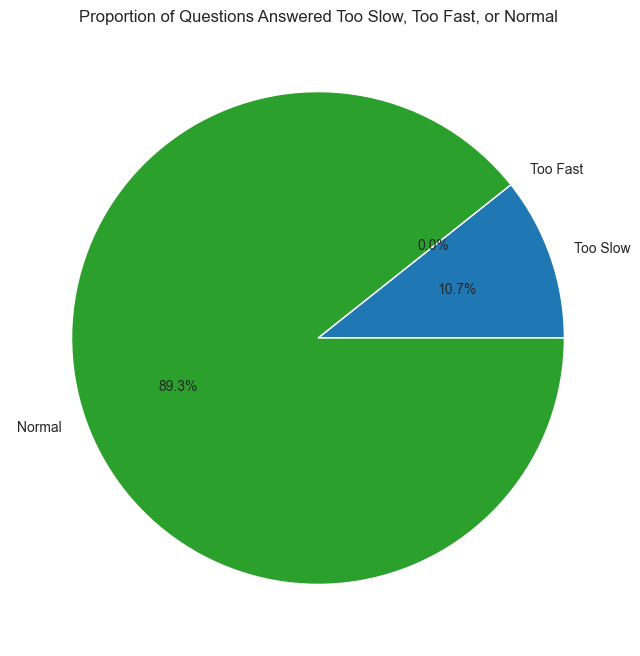

In [14]:
too_slow_count = df_timespent['TooSlow'].sum()
too_fast_count = df_timespent['TooFast'].sum()
normal_count = len(df_timespent) - too_slow_count - too_fast_count

plt.figure(figsize=(8, 8))
plt.pie([too_slow_count, too_fast_count, normal_count], 
        labels=['Too Slow', 'Too Fast', 'Normal'], 
        autopct='%1.1f%%')
plt.title('Proportion of Questions Answered Too Slow, Too Fast, or Normal')
plt.show()